In [ ]:
# Fig. 3.1 and 4.6
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import umap
import ot

sys.path.insert(0, os.path.dirname(os.path.abspath(".")))
from src.universal_feature_extractor import UniversalFeatureExtractor
from src.DatasetFeatureLoader import DatasetFeatureLoader
from src.utils import make_deterministic

SEED = 42
make_deterministic(SEED)

SAR_PATH = "/workspace/mnt-data/SEN12-splits/train/input"
OPT_PATH = "/workspace/mnt-data/SEN12-splits/train/target"

POOL_SIZE = 1000
MODEL_NAME = ["resnet18", "dinov2"]

Initializing Model: RESNET18


/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


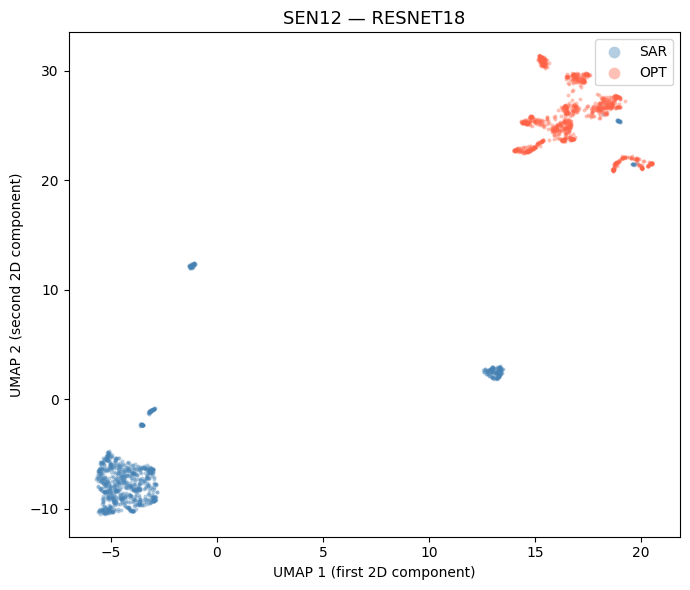

Initializing Model: DINOV2


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov2_main
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
/opt/conda/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


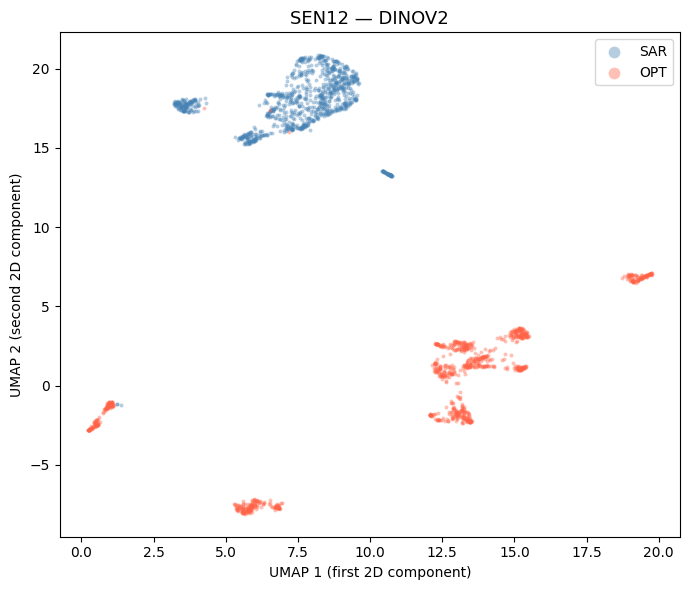

In [5]:
for MODEL in MODEL_NAME:
    extractor = UniversalFeatureExtractor(MODEL)
    loader = DatasetFeatureLoader(extractor, pool_size=POOL_SIZE, seed=SEED)

    sar_features = loader.load(SAR_PATH, "SAR-SEN12")
    opt_features = loader.load(OPT_PATH, "OPT-SEN12")

    sar_features = sar_features
    opt_features = opt_features
    all_features = np.vstack([sar_features, opt_features])
    labels = np.array([0] * len(sar_features) + [1] * len(opt_features))

    embedding = umap.UMAP(n_components=2, random_state=SEED).fit_transform(all_features)

    fig, ax = plt.subplots(figsize=(7, 6))

    for idx, (label, color) in enumerate([("SAR", "steelblue"), ("OPT", "tomato")]):
        mask = labels == idx
        ax.scatter(
            embedding[mask, 0],
            embedding[mask, 1],
            label=label,
            color=color,
            alpha=0.4,
            s=8,
            linewidths=0,
        )

    ax.set_title(f"SEN12 — {MODEL.upper()}", fontsize=13)
    ax.set_xlabel("UMAP 1 (first 2D component)")
    ax.set_ylabel("UMAP 2 (second 2D component)")
    ax.legend(markerscale=3)

    plt.tight_layout()
    plt.show()